# Exploratory Data Analysis

Exploratory Data Analysis (EDA) is an important step in data analysis where we explore, summarize, and visualize data to understand its structure, detect patterns, identify anomalies, test assumptions, and check relationships between variables before applying any machine learning or statistical models.

In [1]:
# load data and import necessary libraries
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/amazon_sales.csv")

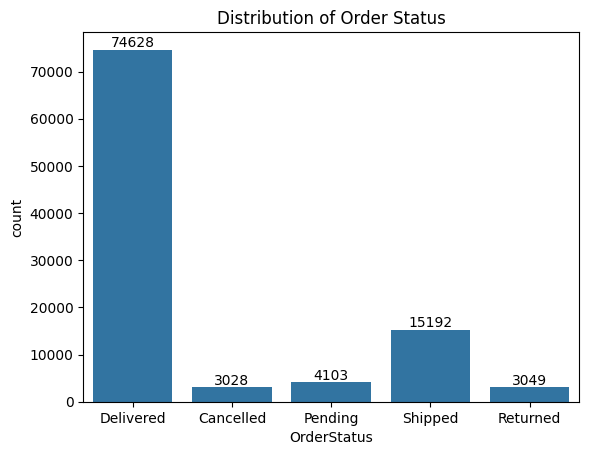

In [3]:
# bar plot for order status
ax = sns.countplot(data=df, x='OrderStatus')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.title('Distribution of Order Status')
plt.show()

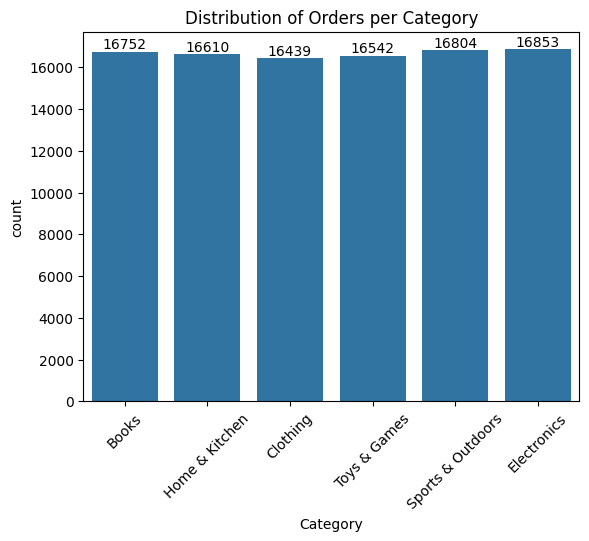

In [6]:

# order count per category

ax = sns.countplot(data=df, x='Category')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
    
plt.title('Distribution of Orders per Category')
plt.xticks(rotation=45)
plt.show()  

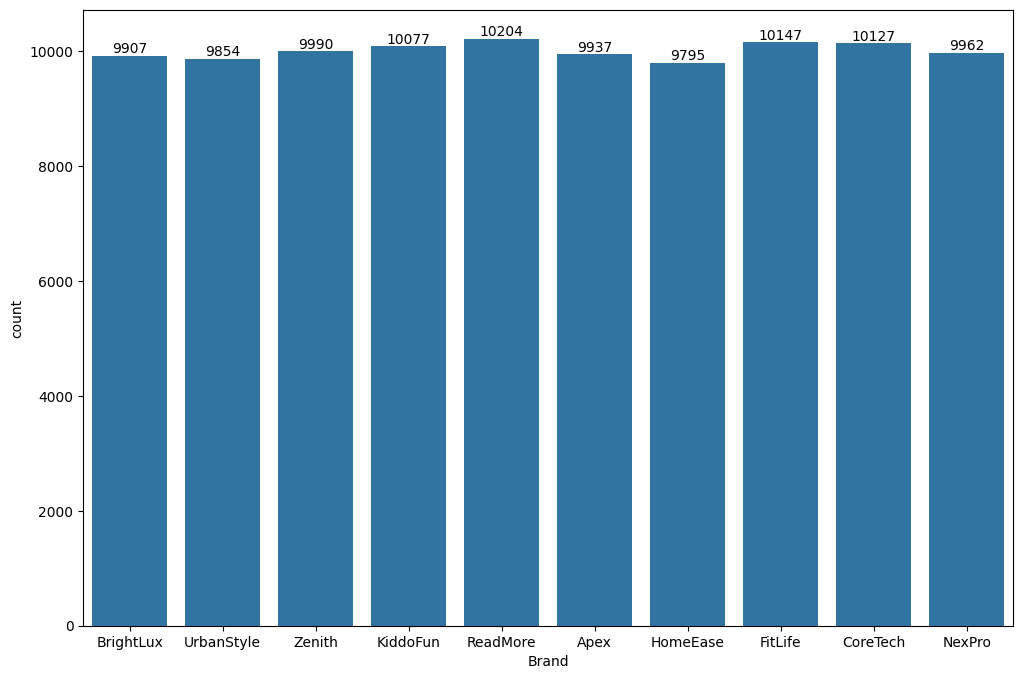

In [4]:

# order count per brand
plt.figure(figsize=(12,8))

ax = sns.countplot(data=df, x='Brand')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

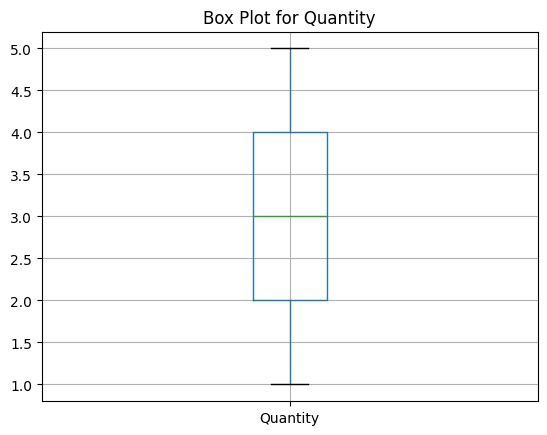

In [7]:
# box plot for quantity col
df.boxplot(column=['Quantity'])
plt.title('Box Plot for Quantity')
plt.show()

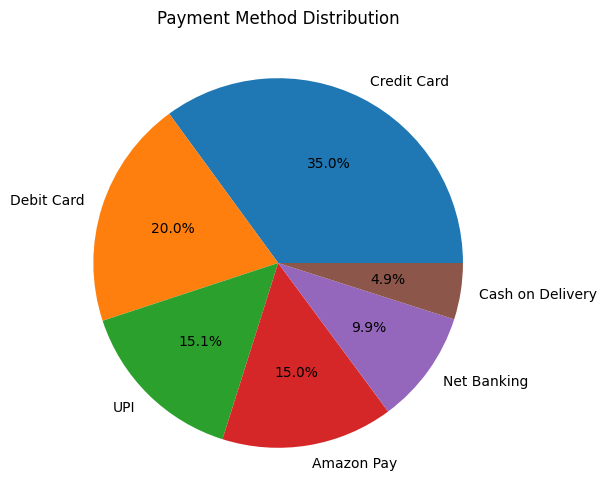

In [2]:
# payment method Distribution
counts = df['PaymentMethod'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%'
)

plt.title("Payment Method Distribution")
plt.show()

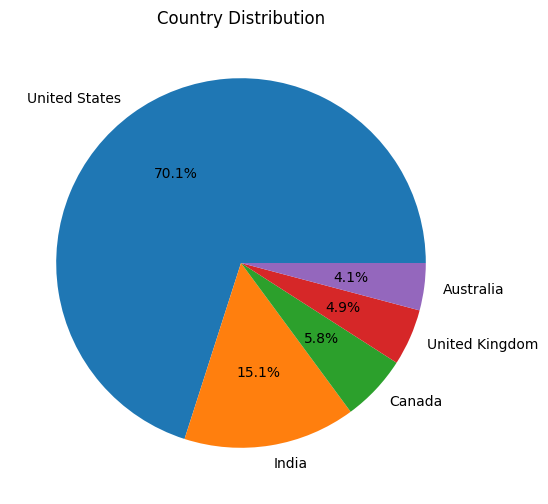

In [3]:
# country Distribution
counts = df['Country'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%'
)

plt.title("Country Distribution")
plt.show()

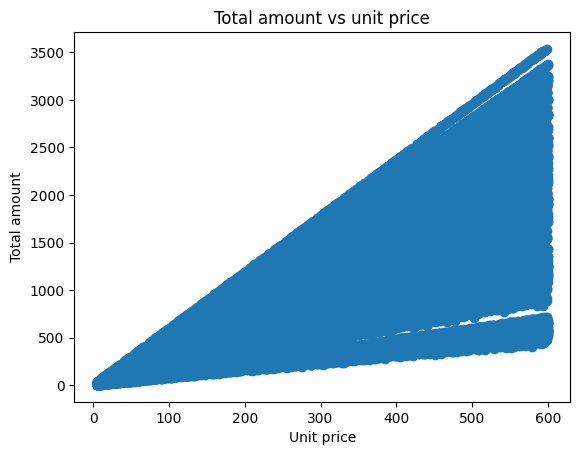

In [8]:
# unit price vs total amount

plt.scatter(df['UnitPrice'], df['TotalAmount'])
plt.title("Total amount vs unit price")
plt.xlabel('Unit price')
plt.ylabel('Total amount')
plt.show()

<Figure size 1500x800 with 0 Axes>

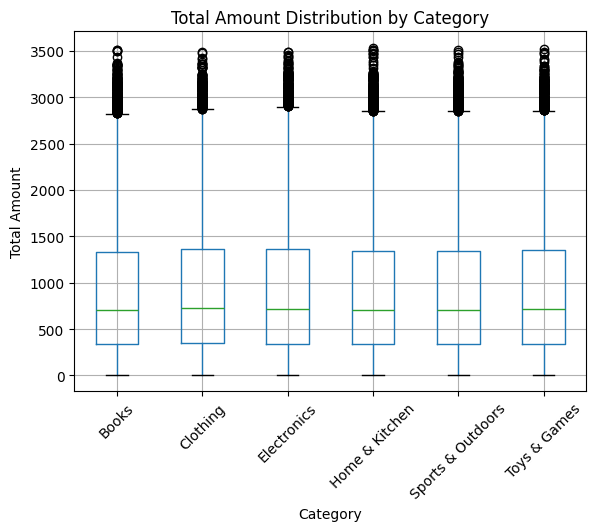

In [8]:

# total amount distribution by category
plt.figure(figsize=(15,8))

df.boxplot(column='TotalAmount', by='Category')

plt.title("Total Amount Distribution by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Total Amount")

plt.xticks(rotation=45)
plt.show()

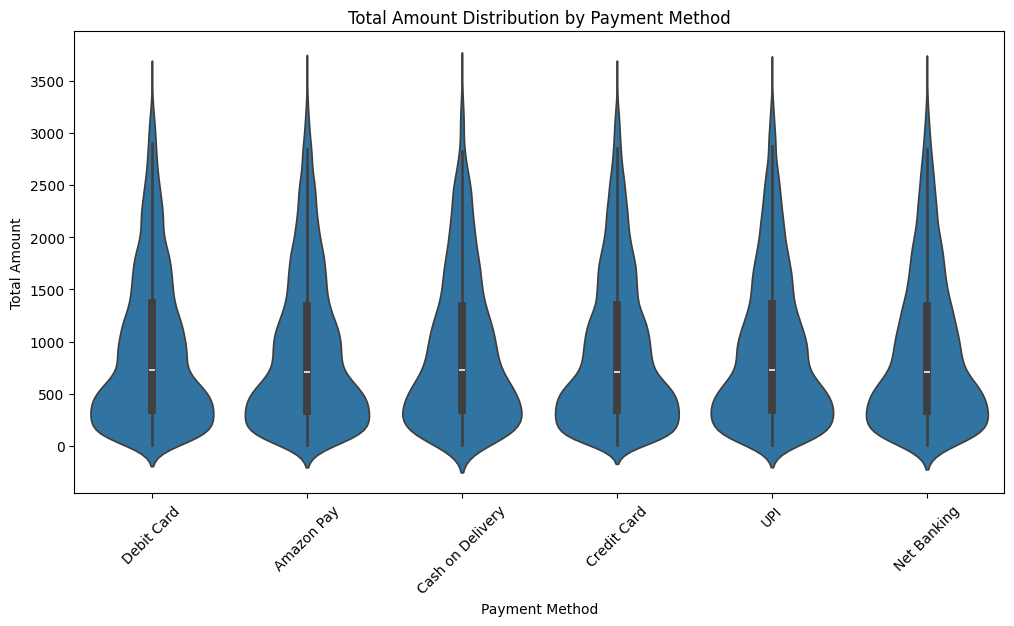

In [10]:

# total amount distribution by payment method
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='PaymentMethod',
    y='TotalAmount',
    inner='box'
)

plt.title("Total Amount Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Amount")

plt.xticks(rotation=45)
plt.show()

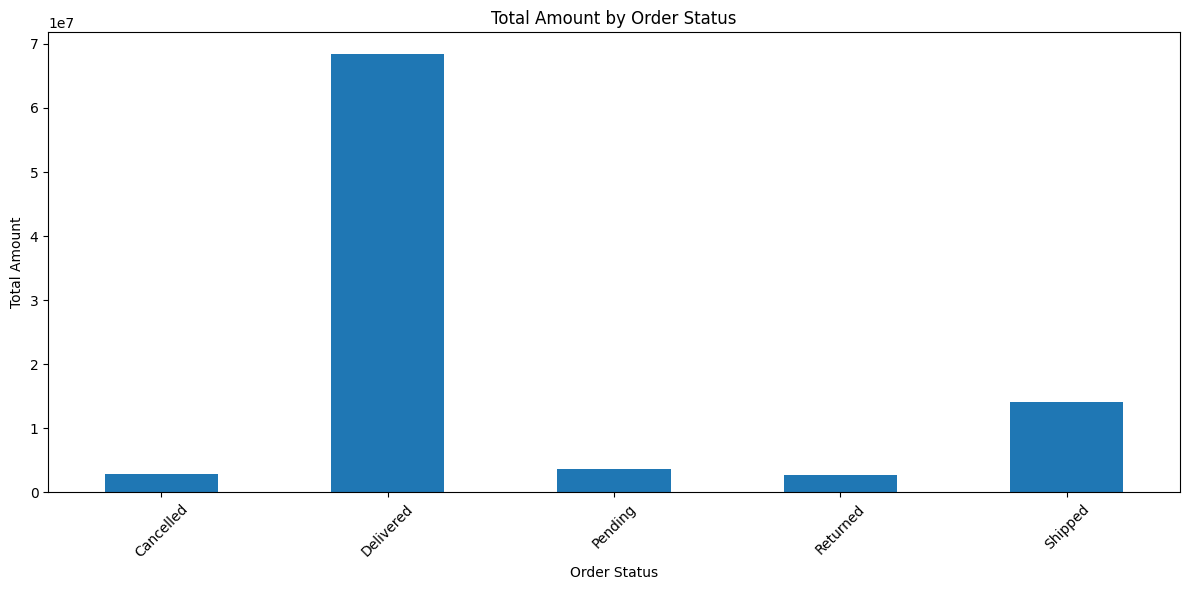

In [11]:
# total amount by order status
pivot_df = df.groupby('OrderStatus')['TotalAmount'].sum()

pivot_df.plot(kind='bar', figsize=(12,6))

plt.title("Total Amount by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Total Amount")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

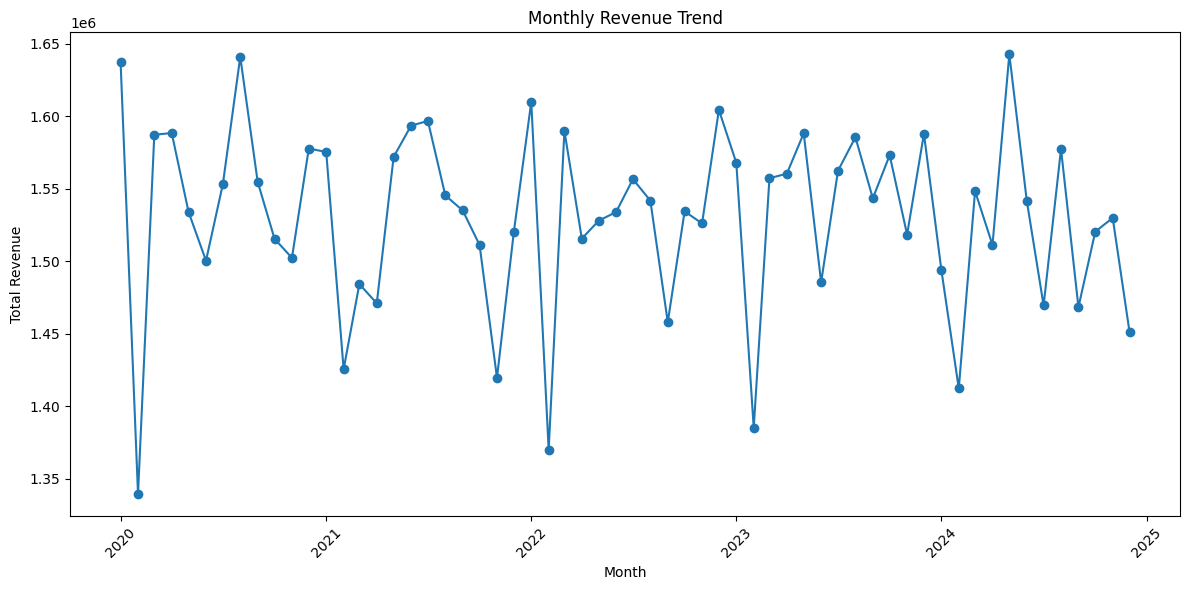

In [4]:
# Ensure datetime format
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

monthly_revenue = df.groupby(df['OrderDate'].dt.to_period('M'))['TotalAmount'].sum()

monthly_revenue.index = monthly_revenue.index.to_timestamp()

plt.figure(figsize=(12,6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

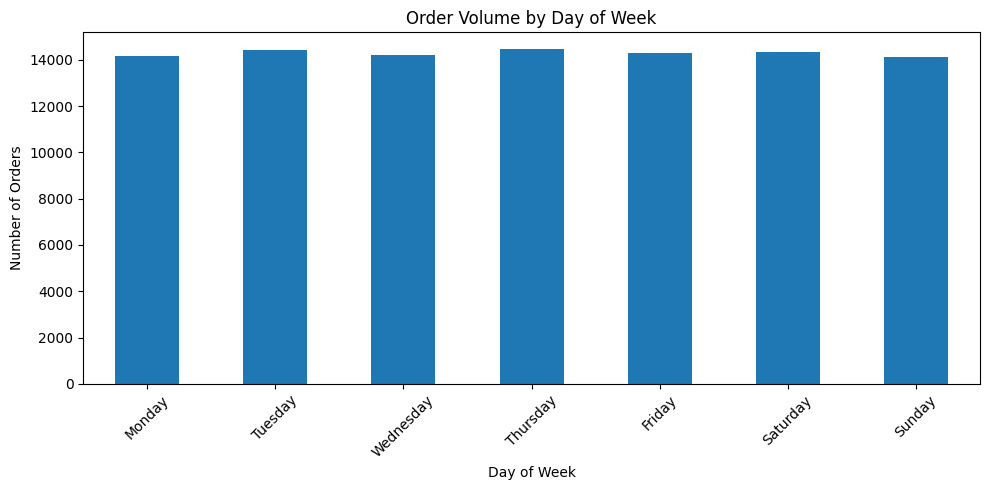

In [ ]:

# Ensure datetime format
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

df['DayOfWeek'] = df['OrderDate'].dt.day_name()

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

order_counts = df['DayOfWeek'].value_counts().reindex(order)

# Plot
plt.figure(figsize=(10,5))
order_counts.plot(kind='bar')

plt.title("Order Volume by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

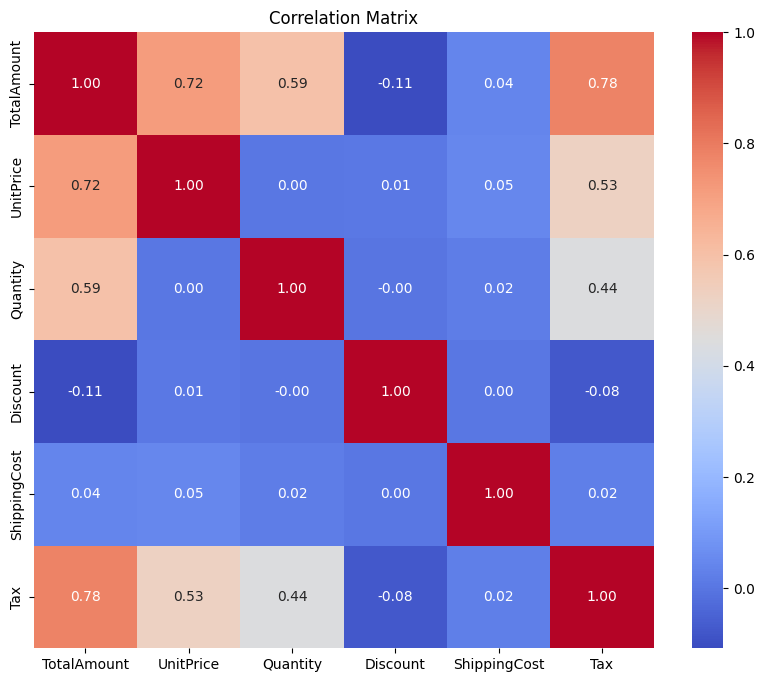

In [5]:

# correlation matrix of num values
corr_matrix = df[[
    'TotalAmount',
    'UnitPrice',
    'Quantity',
    'Discount',
    'ShippingCost',
    'Tax',
]].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

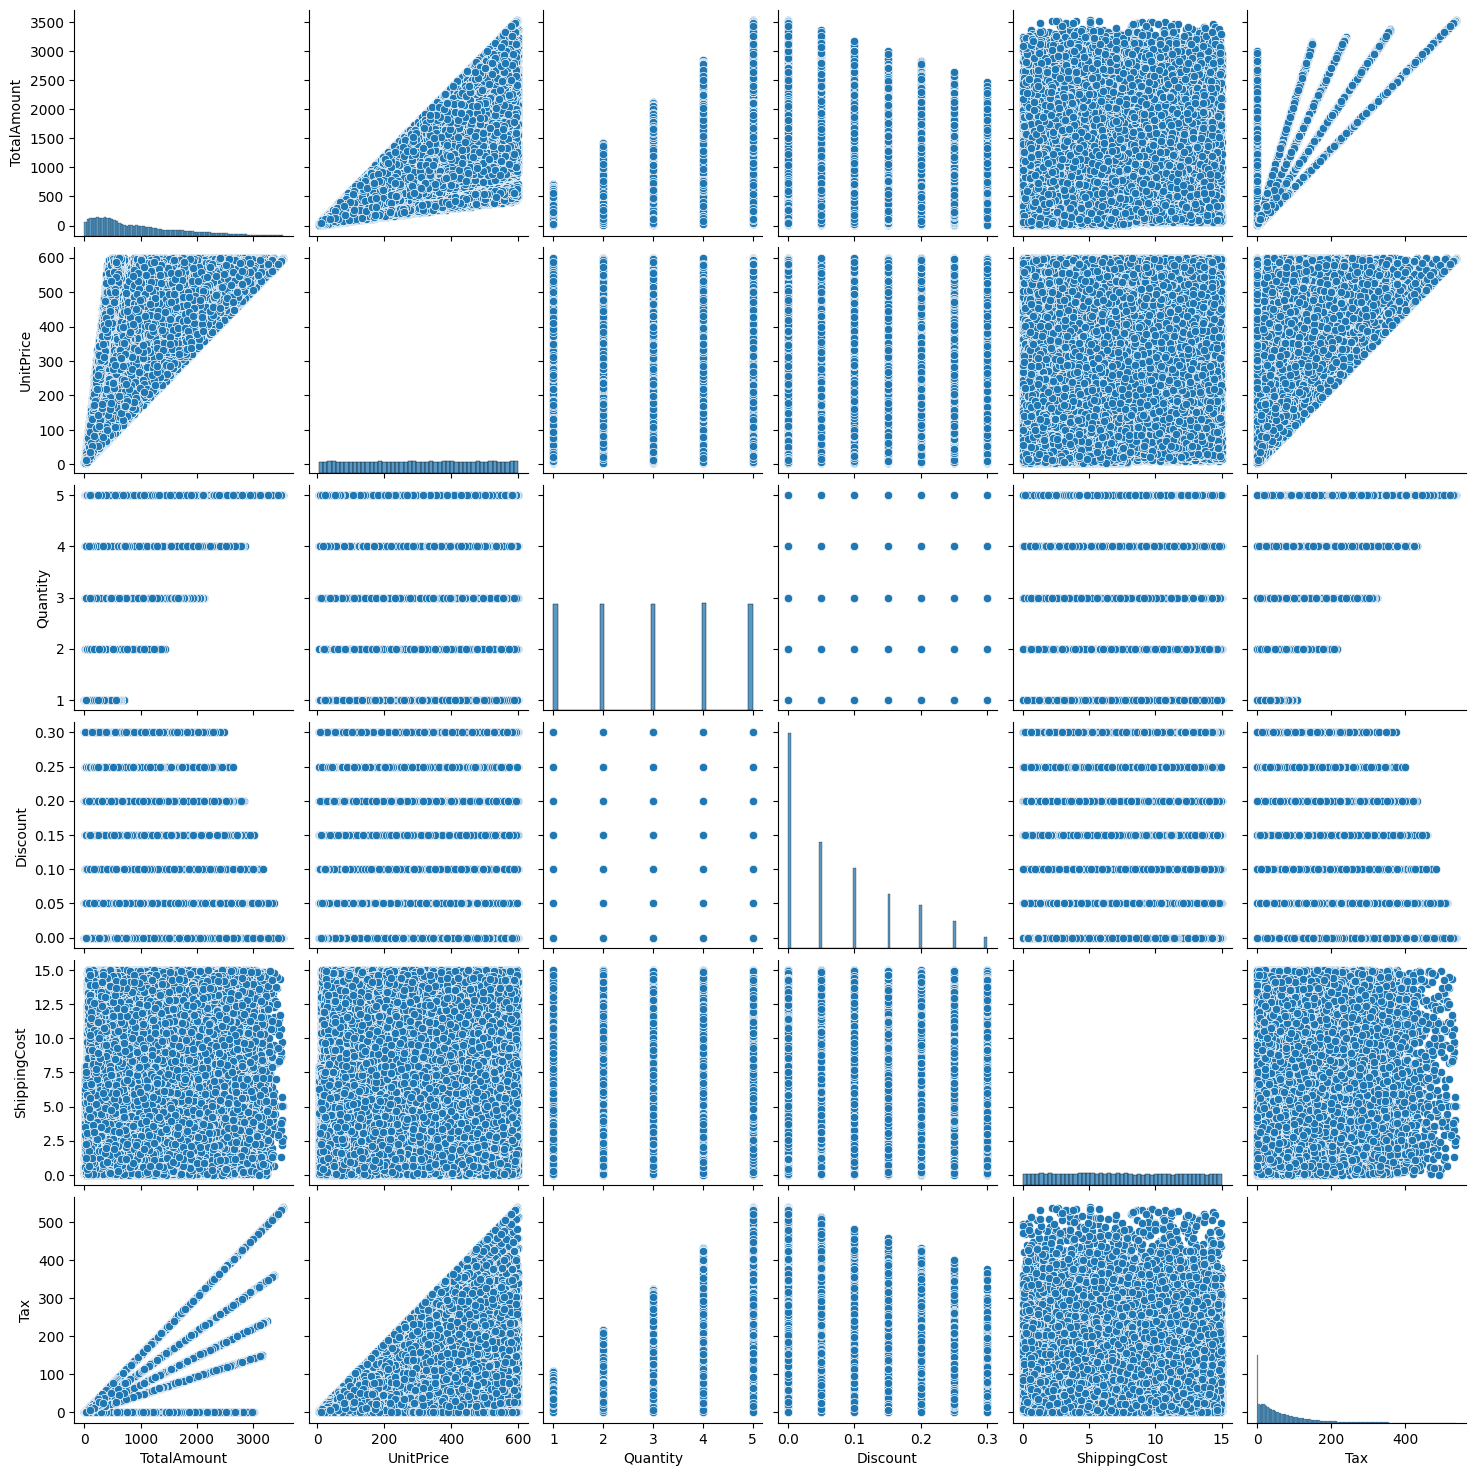

In [19]:
# Select numeric columns 
num_cols = [
    'TotalAmount',
    'UnitPrice',
    'Quantity',
    'Discount',
    'ShippingCost',
    'Tax',
]

sns.pairplot(df[num_cols])

plt.show()

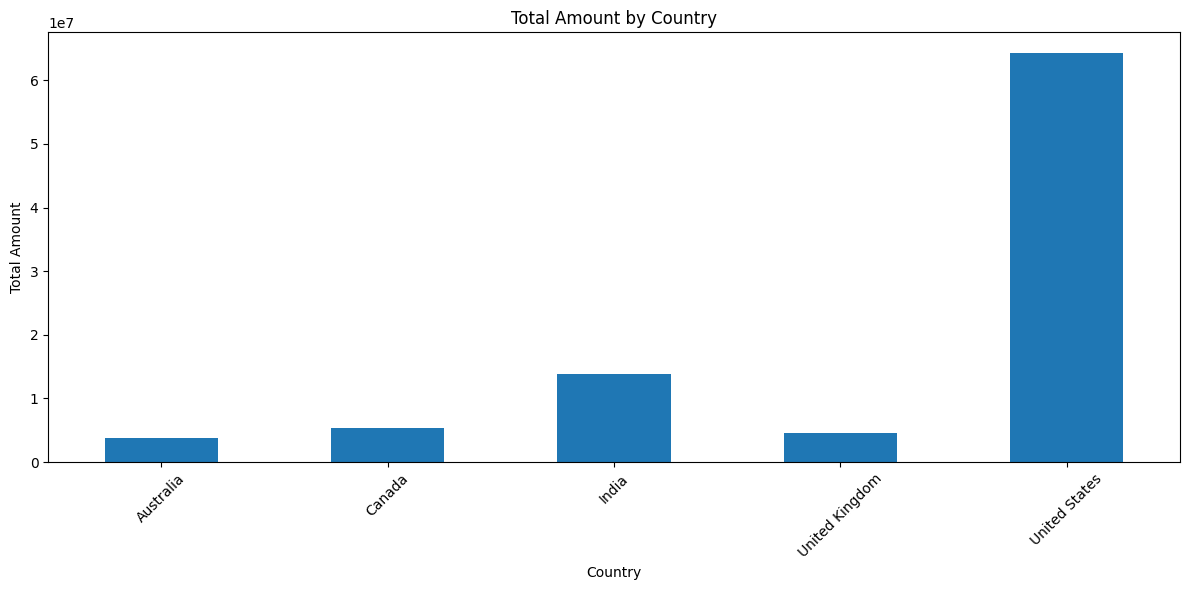

In [20]:
# total amount by country
pivot_df = df.groupby('Country')['TotalAmount'].sum()

pivot_df.plot(kind='bar', figsize=(12,6))

plt.title("Total Amount by Country")
plt.xlabel("Country")
plt.ylabel("Total Amount")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

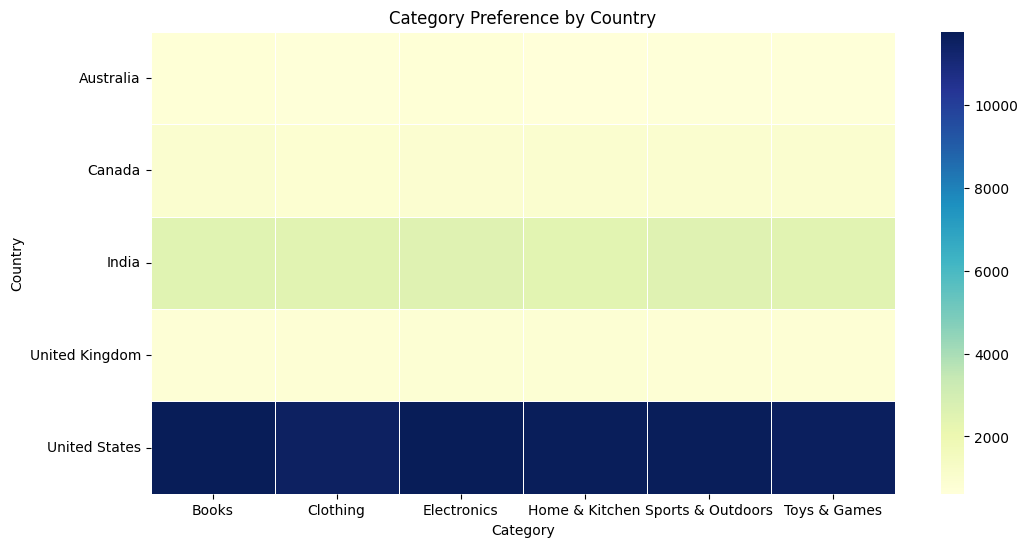

In [ ]:
pivot_df = pd.pivot_table(
    df,
    values='OrderID',
    index='Country',
    columns='Category',
    aggfunc='count',
    fill_value=0
)
plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_df,
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title("Category Preference by Country")
plt.xlabel("Category")
plt.ylabel("Country")

plt.show()